In [1]:
import os
import ot
import gc
import k3d
import torch
import trimesh
import warnings
from tqdm import *
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import seaborn as sns
from pathlib import Path
import scipy.sparse as sp
import matplotlib.cm as cm
from anndata import AnnData
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from numpy.random import RandomState
import matplotlib.font_manager as fm
from matplotlib.gridspec import GridSpec
from sklearn.metrics import jaccard_score
from scipy.stats import fisher_exact, norm
from sklearn.neighbors import NearestNeighbors
from typing import Literal, Optional, Tuple, Union
from matplotlib.colors import ListedColormap, rgb2hex
from sklearn.metrics.pairwise import euclidean_distances
from matplotlib.font_manager import fontManager, FontProperties
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

In [2]:
def gene_3d_plot(h5ad_input, 
                 gene, 
                 output_path, 
                 cmap,
                 camera,
                 basis="ccf",
                ):
    """
    根据给定的 h5ad 和基因列表生成 k3d 3D 散点图并保存为 HTML。
    :param h5ad_input: str (h5ad 文件路径) 或 AnnData 对象
    :param gene_list: list, 需要绘制的基因名称列表
    :param output_html: str, 保存的 HTML 文件名
    :param basis: str, obsm 中用于 3D 坐标的键 (如 'X_umap', 且需包含 3 列)
    """
    if isinstance(h5ad_input, str):
        adata = sc.read_h5ad(h5ad_input)
    else:
        adata = h5ad_input

    if basis not in adata.obsm.keys():
        raise ValueError(f"在 adata.obsm 中找不到 {basis}")
        
    coords = adata.obsm[basis] * 10
    if coords.shape[1] < 3:
        raise ValueError(f"坐标 {basis} 的维度小于 3，无法进行 3D 绘图")
    positions = coords[:, :3].astype(np.float32)

    
    plot = k3d.plot(name="Gene Expression 3D Plot",background_color=0xffffff,camera_auto_fit=True)
    
    if gene not in adata.var_names:
        print(f"警告：基因 {gene} 不在数据集中，已跳过。")
        return
        
    expr = adata[:, gene].X
    if hasattr(expr, "toarray"):
        expr = expr.toarray()
    expr = expr.flatten()
    mask = expr > 0

    if not np.any(mask):
        print(f"{gene}: 无表达细胞，跳过")
        return

    expr = expr[mask]
    positions = coords[mask] 

    expr_min, expr_max = expr.min(), expr.max()
    if expr_max > expr_min:
        expr_norm = (expr - expr_min) / (expr_max - expr_min)
    else:
        expr_norm = np.zeros_like(expr)

    cmap = cmap
    colors = cmap(expr_norm)

    colors_hex = (
        (np.clip(colors[:, 0] * 255, 0, 255).astype(np.uint32) << 16) |
        (np.clip(colors[:, 1] * 255, 0, 255).astype(np.uint32) << 8) |
        (np.clip(colors[:, 2] * 255, 0, 255).astype(np.uint32))
    )

    point_cloud = k3d.points(
        positions, 
        colors=colors_hex, 
        point_size=150.0, 
        opacities = expr,
        shader='3d', 
        name=gene
    )

    plot += point_cloud
    # plot.camera = camera
    plot.grid_visible = False
    with open(os.path.join(output_path,gene+'.html'), 'w', encoding='utf-8') as f:
        f.write(plot.get_snapshot())
    return plot

In [3]:
import matplotlib.colors as mcolors
hex_colors = ['#0000FF','#0CFDF1', '#FFFF00', '#FF0000', '#D60000'] 
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', hex_colors)

In [4]:
adata_path = '/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/02_macaque_brain_mae/cache/adatas'
adata_list = [i for i in os.listdir(adata_path) if i.endswith('.h5ad')]
genes = [
            "SLC17A7", #"GPR83", "CCBE1", "CUX2", "GPC5", "PDZD2", "CUX1", "MYLK", 
            # "RORB", "IL1RAPL2", "ETV1", "TLE4", "SEMA3E", "GAD1", "GAD2", "ADARB2", "LAMP5", 
            # "FBXL7", "KIT", "EYA4", "CALB2", "RELN", "VIP", "SOX6", "TRPS1", "ADAMTSL1", 
            # "PVALB", "POSTN", "SST", "CALB1", "SLC1A2", "SLC1A3", "PTPRZ1", "PDGFRA", 
            # "COL9A1", "PLP1", "ITGAM", "RGS5", "COL1A2"
        ]
adatas = []
for adata_li in adata_list:
    adata = sc.read_h5ad(os.path.join(adata_path, adata_li))
    adata = adata[:,genes].copy()
    del adata.obsm['adj_norm']
    del adata.obsm['spatial_input']
    adatas.append(adata)
    gc.collect()

In [5]:
adata = ad.concat(adatas)
adata

/home/share/huadjyin/home/zhoutao3/.conda/envs/stereotrack_2/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 30975704 × 1
    obs: 'x', 'y', 'rx', 'ry', 'gene_area', 'celltype', 'SubClass', 'Class', 'rz'
    obsm: 'ccf'

In [6]:
adata.obsm['ccf'][:,2] = adata.obsm['ccf'][:,2]*1.5

In [16]:
import os
import numpy as np
import scanpy as sc
import k3d

def gene_and_celltype_3d_plot(h5ad_input, 
                              gene, 
                              output_path, 
                              cmap,
                              cell_types,
                              cell_type_cmap,
                              camera=None,
                              basis="ccf"):
    if isinstance(h5ad_input, str):
        adata = sc.read_h5ad(h5ad_input)
    else:
        adata = h5ad_input

    if basis not in adata.obsm.keys():
        raise ValueError(f"在 adata.obsm 中找不到 {basis}")
        
    coords = adata.obsm[basis]
    if coords.shape[1] < 3:
        raise ValueError(f"坐标 {basis} 的维度小于 3，无法进行 3D 绘图")
    
    positions = coords[:, :3].astype(np.float32)

    x_max = np.max(positions[:, 0])
    mirrored_positions = positions.copy()
    mirrored_positions[:, 0] = 2 * x_max - mirrored_positions[:, 0] + 200

    ct_color_dict_int = {k: int(v.lstrip('#'), 16) for k, v in cell_type_cmap.items()}
    
    ct_colors = np.array([ct_color_dict_int.get(ct, 0xCCCCCC) for ct in cell_types], dtype=np.uint32)
    
    
    
    plot = k3d.plot(name="Half Brain Gene & Half Brain CellType", background_color=0xffffff, camera_auto_fit=False)
    plot.grid_visible = False
    
    mesh = trimesh.load('/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/example/02_Chen_Cell/3d_plot/4_makemesh_for_macaque_v2.obj')
    stl_mesh = k3d.mesh(
        vertices=mesh.vertices,
        indices  =mesh.faces,
        color    =0xB0B0B0,
        opacity  =0.10,
        wireframe=False,
        name='macaqueMesh'
    )
    plot += stl_mesh
    
    

    # point_cloud_ct = k3d.points(
    #     mirrored_positions, 
    #     colors=ct_colors, 
    #     point_size=20.0, 
    #     shader='3d', 
    #     name="Cell Types (Mirrored)"
    # )
    # plot += point_cloud_ct

    if gene not in adata.var_names:
        print(f"警告：基因 {gene} 不在数据集中，将只绘制细胞类型镜像。")
    else:
        expr = adata[:, gene].X
        if hasattr(expr, "toarray"):
            expr = expr.toarray()
        expr = expr.flatten()
        mask = expr > 0
        print('here')
        if not np.any(mask):
            print(f"{gene}: 无表达细胞，跳过基因侧绘制。")
        else:
            expr_filtered = expr[mask]
            positions_filtered = positions[mask] 

            expr_min, expr_max = expr_filtered.min(), expr_filtered.max()
            if expr_max > expr_min:
                expr_norm = (expr_filtered - expr_min) / (expr_max - expr_min)
            else:
                expr_norm = np.zeros_like(expr_filtered)

            colors_rgba = cmap(expr_norm)
            colors_hex = (
                (np.clip(colors_rgba[:, 0] * 255, 0, 255).astype(np.uint32) << 16) |
                (np.clip(colors_rgba[:, 1] * 255, 0, 255).astype(np.uint32) << 8) |
                (np.clip(colors_rgba[:, 2] * 255, 0, 255).astype(np.uint32))
            )

            point_cloud_gene = k3d.points(
                positions_filtered, 
                colors=colors_hex, 
                point_size=20.0, 
                opacities=expr_filtered,
                shader='3d', 
                name=gene
            )
            plot += point_cloud_gene

    if camera is not None:
        plot.camera = camera

    output_file = os.path.join(output_path, f'{gene}_mirrored.html')
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(plot.get_snapshot())
        
    return plot

In [ ]:
adata

In [8]:
output_path="/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/example/02_Chen_Cell/3d_plot/raw"

In [9]:
gene = 'SLC17A7'

In [29]:
camera = [208553.0642918199,
 -151970.10003125155,
 957894.2810783959,
 370389.62109375,
 511455.375,
 156600,
 0.29037801298345595,
 -0.797489233816011,
 -0.5288587065779492]


In [11]:
import json

json_file = '/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/example/02_Chen_Cell/3d_plot/colormap_extracted.json'
with open(json_file, 'r', encoding='utf-8') as f:
    colormap = json.load(f)
json_file = '/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/example/02_Chen_Cell/3d_plot/id_to_name.json'
with open(json_file, 'r', encoding='utf-8') as f:
    id_to_name = json.load(f)

In [21]:
plot = gene_and_celltype_3d_plot(
    adata, 
    gene, 
    output_path = output_path,
    basis="ccf",
    cmap = cmap,
    cell_types=[id_to_name[str(int(i))] for i in adata.obs['gene_area']],
    cell_type_cmap=colormap,
    camera=[-23549.10148899872,
 35656.5243828245,
 61634.33459188209,
 65292.640818004795,
 54386.76531008438,
 15833.198390523024,
 0.04975933578978034,
 -0.982019638264275,
 -0.18210282415458562]
 )

here


In [22]:
1

1

In [23]:
plot

Plot(antialias=3, axes=['x', 'y', 'z'], axes_helper=1.0, axes_helper_colors=[16711680, 65280, 255], background…

In [20]:
plot.camera

[-23549.10148899872,
 35656.5243828245,
 61634.33459188209,
 65292.640818004795,
 54386.76531008438,
 15833.198390523024,
 0.04975933578978034,
 -0.982019638264275,
 -0.18210282415458562]

In [22]:
plot = gene_and_celltype_3d_plot(
    adata, 
    gene, 
    output_path = output_path,
    basis="ccf",
    cmap = cmap,
    camera=None
 )

In [28]:
plot.camera

[208553.0642918199,
 -151970.10003125155,
 957894.2810783959,
 370389.62109375,
 511455.375,
 156600,
 0.29037801298345595,
 -0.797489233816011,
 -0.5288587065779492]

In [67]:
t = sc.read_h5ad('/home/share/huadjyin/home/zhoutao3/tracks/example_data/07_macaque_brain/cortex/T33.h5ad')
t.obs['region'] = [id_to_name[str(int(i))] for i in t.obs['gene_area']]

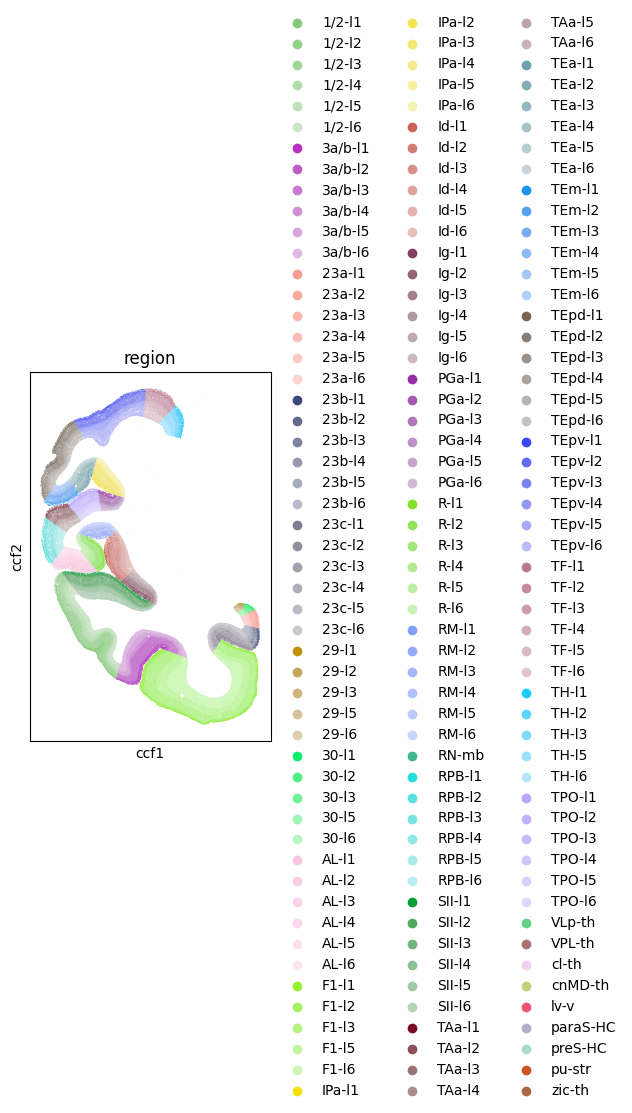

In [68]:
plot = sc.pl.embedding(t, color = 'region', basis = 'ccf', palette = colormap, show = False)
plot.set_aspect('equal')

In [ ]:
#C1BAF2